# 2. 网格降雨数据处理与流域面平均计算

本节将演示如何使用**面积占比法**处理网格降雨数据，计算流域面平均降雨量。

## 方法说明
- **数据源(任选一种)**: 
  - MSWEP: 使用文件夹下示例的2021年数据
  - GFS: 使用2024年数据作为示例
- **计算方法**: 面积占比法（Grid Area-Weighted Method）
- **示例**: 使用1个流域，全年数据

## 1. 导入必要的库

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point, Polygon, box
from datetime import datetime, timedelta
import glob
import os
import time
import warnings
import random
import rasterio
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")

所有库导入成功！


## 2. 加载流域数据

从 shapefile 中随机选择流域进行演示（与第一个notebook使用相同的随机种子确保可复现）。

In [ ]:
# 读取流域 shapefile
shapefile_path = "/ftproot/watergpt/shapes/basins.shp"  # 请根据实际路径调整
basins_gdf = gpd.read_file(shapefile_path)

# ============ 自定义选择流域数量 ============
NUM_BASINS = 1  # 选择流域的数量，默认为1

# 使用与上一个notebook相同的随机种子，确保选择相同的流域
random.seed(42)

# 从所有流域中随机选择指定数量的流域
if NUM_BASINS > len(basins_gdf):
    print(f"警告: 请求的流域数量 ({NUM_BASINS}) 超过总数 ({len(basins_gdf)})，将选择所有流域")
    NUM_BASINS = len(basins_gdf)

random_indices = random.sample(range(len(basins_gdf)), NUM_BASINS)
selected_basins = basins_gdf.iloc[random_indices].copy()

print(f"随机选择了 {NUM_BASINS} 个流域（与notebook 1保持一致）")
print(f"流域索引: {random_indices}")
print(f"\n选中的流域信息:")
for idx, (i, basin) in enumerate(selected_basins.iterrows()):
    basin_id = basin['BASIN_ID']
    basin_area = basin['AREA']
    print(f"  {idx+1}. 流域ID: {basin_id}, 面积: {basin_area:.2f} km²")

# 如果只选择一个流域，将其设为示例流域
if NUM_BASINS == 1:
    example_basin = selected_basins
    basin_id = example_basin['BASIN_ID'].values[0]
    basin_area = example_basin['AREA'].values[0]
    
    print(f"\n示例流域:")
    print(f"  BASIN_ID: {basin_id}")
    print(f"  流域面积: {basin_area:.2f} km²")
    
    # 获取流域边界
    basin_bounds = example_basin.total_bounds
    print(f"  流域边界 [minx, miny, maxx, maxy]: {basin_bounds}")
else:
    # 多个流域时，使用第一个作为示例
    example_basin = selected_basins.iloc[0:1]
    basin_id = example_basin['BASIN_ID'].values[0]
    basin_area = example_basin['AREA'].values[0]
    
    print(f"\n使用第一个流域作为示例:")
    print(f"  BASIN_ID: {basin_id}")
    print(f"  流域面积: {basin_area:.2f} km²")
    
    # 获取流域边界
    basin_bounds = example_basin.total_bounds
    print(f"  流域边界 [minx, miny, maxx, maxy]: {basin_bounds}")

# 获取流域几何对象
basin_geom = example_basin.geometry.values[0]

print(f"\n提示: 修改 NUM_BASINS 参数可以选择不同数量的流域")

随机选择了 1 个流域（与notebook 1保持一致）
流域索引: [5238]

选中的流域信息:
  1. 流域ID: grdc_6503120, 面积: 815.35 km²

示例流域:
  BASIN_ID: grdc_6503120
  流域面积: 815.35 km²
  流域边界 [minx, miny, maxx, maxy]: [-8.8625     52.30833333 -8.275      52.58333333]

提示: 修改 NUM_BASINS 参数可以选择不同数量的流域


## 3. 面积占比法计算流域面平均降雨

**算法原理**:
$$
\bar{P} = \frac{\sum_{i=1}^{n} P_i \cdot A_i}{\sum_{i=1}^{n} A_i}
$$

其中:
- $\bar{P}$ 为流域面平均降雨
- $P_i$ 为第 $i$ 个网格的降雨量
- $A_i$ 为第 $i$ 个网格与流域的交集面积
- $n$ 为与流域相交的网格总数

以下定义公共函数，MSWEP和GFS数据处理都将调用此函数。

In [ ]:
def calculate_grid_weights_fast(basin_geom, lats, lons):
    """
    快速计算网格权重
    
    参数:
        basin_geom: 流域几何对象
        lats: 纬度数组 (1D)
        lons: 经度数组 (1D)
    
    返回:
        weights: 归一化权重矩阵 (lat, lon)
    """
    resolution_lat = abs(np.diff(lats).mean()) if len(lats) > 1 else 0.1
    resolution_lon = abs(np.diff(lons).mean()) if len(lons) > 1 else 0.1
    
    weights = np.zeros((len(lats), len(lons)))
    
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            grid_cell = box(
                lon - resolution_lon / 2,
                lat - resolution_lat / 2,
                lon + resolution_lon / 2,
                lat + resolution_lat / 2
            )
            
            if grid_cell.intersects(basin_geom):
                intersection = grid_cell.intersection(basin_geom)
                weights[i, j] = intersection.area
    
    # 归一化
    total_weight = weights.sum()
    if total_weight > 0:
        weights = weights / total_weight
    
    return weights

print('面积占比函数已创建')

面积占比函数已创建


## 4. 加载MSWEP数据并计算流域面平均降雨

4.1 设置MSWEP数据配置

In [9]:
# ============ MSWEP数据配置 ============
MSWEP_DATA_DIR = "/ftproot/mswep_3h/NRT/3hourly"           # 数据文件夹路径: "Daily" 或 "3hourly"
MSWEP_START_DATE = "2021-01-01"   # 开始日期
MSWEP_END_DATE = "2021-12-31"     # 结束日期
TIME_SCALE = "3hourly"               # 时间尺度: "daily" 或 "3hourly"
# ========================================

print(f"MSWEP数据处理配置:")
print(f"  数据目录: {MSWEP_DATA_DIR}")
print(f"  时间范围: {MSWEP_START_DATE} 至 {MSWEP_END_DATE}")
print(f"  时间尺度: {TIME_SCALE}")
print(f"  流域数量: {len(selected_basins)}")

MSWEP数据处理配置:
  数据目录: /ftproot/mswep_3h/NRT/3hourly
  时间范围: 2021-01-01 至 2021-12-31
  时间尺度: 3hourly
  流域数量: 1


4.2 处理MSWEP数据并计算（调用公共函数）

In [10]:
def parse_mswep_filename(filename, time_scale="daily"):
    """
    从MSWEP文件名解析日期
    
    参数:
        filename: 文件名 (例如 "2021001.nc" 或 "2021001.03.nc")
        time_scale: "daily" 或 "3hourly"
    
    返回:
        datetime对象
    """
    basename = os.path.basename(filename).replace('.nc', '')
    
    if time_scale == "daily":
        # 格式: 2021001.nc -> 2021年第1天
        year_doy = basename
        if len(year_doy) == 7:  # YYYYDDD
            year = int(year_doy[:4])
            doy = int(year_doy[4:])
            date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy-1)
            return date
    elif time_scale == "3hourly":
        # 格式: 2021001.03.nc -> 2021年第1天 03:00
        parts = basename.split('.')
        if len(parts) >= 2:
            year_doy = parts[0]
            hour = int(parts[1])
            year = int(year_doy[:4])
            doy = int(year_doy[4:])
            date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy-1, hours=hour)
            return date
    
    return None

def get_mswep_files_in_range(data_dir, start_date, end_date, time_scale="daily"):
    """
    获取时间范围内的MSWEP文件列表
    
    参数:
        data_dir: 数据目录
        start_date: 开始日期 (字符串 "YYYY-MM-DD")
        end_date: 结束日期 (字符串 "YYYY-MM-DD")
        time_scale: "daily" 或 "3hourly"
    
    返回:
        文件列表和对应的日期列表
    """
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    
    all_files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))
    selected_files = []
    selected_dates = []
    
    for file in all_files:
        date = parse_mswep_filename(file, time_scale)
        if date is not None and start <= date <= end:
            selected_files.append(file)
            selected_dates.append(date)
    
    return selected_files, selected_dates

def calculate_grid_weights_fast(basin_geom, lats, lons):
    """
    快速计算网格权重（只计算一次）
    
    参数:
        basin_geom: 流域几何对象
        lats: 纬度数组
        lons: 经度数组
    
    返回:
        weights: 归一化权重矩阵
    """
    resolution_lat = abs(np.diff(lats).mean()) if len(lats) > 1 else 0.1
    resolution_lon = abs(np.diff(lons).mean()) if len(lons) > 1 else 0.1
    
    weights = np.zeros((len(lats), len(lons)))
    
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            grid_cell = box(
                lon - resolution_lon / 2,
                lat - resolution_lat / 2,
                lon + resolution_lon / 2,
                lat + resolution_lat / 2
            )
            
            if grid_cell.intersects(basin_geom):
                intersection = grid_cell.intersection(basin_geom)
                weights[i, j] = intersection.area
    
    # 归一化
    total_weight = weights.sum()
    if total_weight > 0:
        weights = weights / total_weight
    
    return weights

def process_mswep_basin_mean(data_dir, selected_basins, start_date, end_date, time_scale="daily", random_seed=42):
    """
    处理MSWEP数据并计算流域面平均降雨
    
    参数:
        data_dir: MSWEP数据目录
        selected_basins: GeoDataFrame 选中的流域
        start_date: 开始日期
        end_date: 结束日期
        time_scale: "daily" 或 "3hourly"
        random_seed: 随机种子
    
    返回:
        DataFrame: 第一列是时间，后续列是各个流域的降雨
        metadata: 元数据字典
    """
    print(f"正在处理 {len(selected_basins)} 个流域的MSWEP数据...")
    start_time = time.time()
    
    # 获取流域信息
    num_basins = len(selected_basins)
    basin_ids = selected_basins['BASIN_ID'].tolist()
    basin_areas = selected_basins['AREA'].tolist()
    
    print(f"  流域数量: {num_basins}")
    print(f"  流域列表: {basin_ids if num_basins <= 5 else basin_ids[:5] + ['...']}")
    print(f"  总面积: {sum(basin_areas):.2f} km²")
    
    # 1. 获取文件列表
    files, dates = get_mswep_files_in_range(data_dir, start_date, end_date, time_scale)
    print(f"  找到 {len(files)} 个文件在时间范围内")
    
    if len(files) == 0:
        raise FileNotFoundError(f"在时间范围 {start_date} 至 {end_date} 内未找到数据文件")
    
    # 2. 为每个流域计算权重
    print(f"  计算各流域网格权重...")
    weights_list = []
    grid_info_list = []
    
    # 读取第一个文件获取网格信息
    sample_ds = xr.open_dataset(files[0])
    lat_name = 'lat' if 'lat' in sample_ds.coords else 'latitude'
    lon_name = 'lon' if 'lon' in sample_ds.coords else 'longitude'
    
    # 检测降水变量名
    prcp_var = None
    for var in ['precipitation', 'precip', 'pr', 'prcp']:
        if var in sample_ds.data_vars:
            prcp_var = var
            break
    if prcp_var is None:
        prcp_var = list(sample_ds.data_vars)[0]
    
    # 获取所有流域的总边界范围（用于裁剪）
    all_bounds = selected_basins.total_bounds
    minx, miny, maxx, maxy = all_bounds
    margin = 0.5
    
    lats_vals = sample_ds[lat_name].values
    lons_vals = sample_ds[lon_name].values
    
    # 判断纬度顺序
    if lats_vals[0] > lats_vals[-1]:
        lat_slice = slice(maxy + margin, miny - margin)
    else:
        lat_slice = slice(miny - margin, maxy + margin)
    
    sample_ds_cropped = sample_ds.sel({
        lat_name: lat_slice,
        lon_name: slice(minx - margin, maxx + margin)
    })
    
    lats = sample_ds_cropped[lat_name].values
    lons = sample_ds_cropped[lon_name].values
    sample_ds.close()
    
    print(f"  网格大小: {len(lats)} × {len(lons)}")
    
    # 为每个流域计算权重
    total_valid_grids = 0
    for idx, (_, basin_row) in enumerate(selected_basins.iterrows()):
        basin_geom = basin_row.geometry
        basin_id = basin_row['BASIN_ID']
        
        weights = calculate_grid_weights_fast(basin_geom, lats, lons)
        valid_grids = (weights > 0).sum()
        total_valid_grids += valid_grids
        
        weights_list.append(weights)
        grid_info_list.append({
            'basin_id': basin_id,
            'valid_grids': valid_grids
        })
        
        if (idx + 1) % 10 == 0 or idx == 0:
            print(f"    流域 {idx+1}/{num_basins}: {basin_id}, 有效网格: {valid_grids}")
    
    # 3. 逐文件处理并计算各流域加权平均
    print(f"  开始计算流域面平均降雨...")
    results = []
    
    for idx, (file, date) in enumerate(zip(files, dates)):
        if (idx + 1) % 50 == 0:
            print(f"    已处理 {idx+1}/{len(files)} 个文件...")
        
        try:
            ds = xr.open_dataset(file)
            
            # 裁剪
            ds_cropped = ds.sel({
                lat_name: lat_slice,
                lon_name: slice(minx - margin, maxx + margin)
            })
            
            # 提取降雨数据
            prcp_data = ds_cropped[prcp_var].values
            
            # 如果有时间维度,取第一个
            if prcp_data.ndim == 3:
                prcp_data = prcp_data[0]
            
            # 计算各流域加权平均
            record = {'time': date}
            for basin_idx, basin_id in enumerate(basin_ids):
                basin_mean = np.sum(prcp_data * weights_list[basin_idx])
                record[basin_id] = basin_mean
            
            results.append(record)
            
            ds.close()
            
        except Exception as e:
            print(f"    警告: 处理文件 {os.path.basename(file)} 失败: {e}")
            continue
    
    # 4. 创建DataFrame
    df = pd.DataFrame(results)
    df = df.sort_values('time').reset_index(drop=True)
    
    # 重新排列列顺序: time在第一列，然后按流域ID排序
    cols = ['time'] + sorted([col for col in df.columns if col != 'time'])
    df = df[cols]
    
    elapsed_time = time.time() - start_time
    
    # 5. 创建元数据
    metadata = {
        'num_basins': num_basins,
        'basin_ids': basin_ids,
        'basin_areas_km2': basin_areas,
        'total_area_km2': sum(basin_areas),
        'start_date': start_date,
        'end_date': end_date,
        'time_scale': time_scale,
        'num_records': len(df),
        'total_grids': total_valid_grids,
        'grid_info': grid_info_list,
        'computation_time_seconds': elapsed_time,
        'data_source': 'MSWEP',
        'method': 'Grid Area-Weighted Method',
        'random_seed': random_seed
    }
    
    print(f"\n  ✓ 处理完成!")
    print(f"  时间点数: {len(df)}")
    print(f"  流域数: {num_basins}")
    print(f"  计算用时: {elapsed_time:.2f} 秒")
    
    return df, metadata

# 执行计算
basin_mean_df, metadata = process_mswep_basin_mean(
    data_dir=MSWEP_DATA_DIR,
    selected_basins=selected_basins,
    start_date=MSWEP_START_DATE,
    end_date=MSWEP_END_DATE,
    time_scale=TIME_SCALE,
    random_seed=42  # 与notebook 1保持一致
)

# 显示结果
print(f"\n流域面平均降雨数据预览:")
print(basin_mean_df.head(10))

print(f"\n计算元数据:")
print(f"  流域数量: {metadata['num_basins']}")
print(f"  流域ID: {metadata['basin_ids']}")
print(f"  时间范围: {metadata['start_date']} 至 {metadata['end_date']}")
print(f"  记录数: {metadata['num_records']}")
print(f"  随机种子: {metadata['random_seed']}")

正在处理 1 个流域的MSWEP数据...
  流域数量: 1
  流域列表: ['grdc_6503120']
  总面积: 815.35 km²
  找到 2913 个文件在时间范围内
  计算各流域网格权重...
  网格大小: 13 × 16
    流域 1/1: grdc_6503120, 有效网格: 19
  开始计算流域面平均降雨...
    已处理 50/2913 个文件...
    已处理 100/2913 个文件...
    已处理 150/2913 个文件...
    已处理 200/2913 个文件...
    已处理 250/2913 个文件...
    已处理 300/2913 个文件...
    已处理 350/2913 个文件...
    已处理 400/2913 个文件...
    已处理 450/2913 个文件...
    已处理 500/2913 个文件...
    已处理 550/2913 个文件...
    已处理 600/2913 个文件...
    已处理 650/2913 个文件...
    已处理 700/2913 个文件...
    已处理 750/2913 个文件...
    已处理 800/2913 个文件...
    已处理 850/2913 个文件...
    已处理 900/2913 个文件...
    已处理 950/2913 个文件...
    已处理 1000/2913 个文件...
    已处理 1050/2913 个文件...
    已处理 1100/2913 个文件...
    已处理 1150/2913 个文件...
    已处理 1200/2913 个文件...
    已处理 1250/2913 个文件...
    已处理 1300/2913 个文件...
    已处理 1350/2913 个文件...
    已处理 1400/2913 个文件...
    已处理 1450/2913 个文件...
    已处理 1500/2913 个文件...
    已处理 1550/2913 个文件...
    已处理 1600/2913 个文件...
    已处理 1650/2913 个文件...
    已处理 1700/2913

4.3 保存MSWEP数据到CSV

In [11]:
# 创建输出目录
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# 生成文件名
if metadata['num_basins'] == 1:
    output_filename = f"{metadata['basin_ids'][0]}_mswep_{TIME_SCALE}_{MSWEP_START_DATE}_{MSWEP_END_DATE}.csv"
else:
    output_filename = f"{metadata['num_basins']}_basins_mswep_{TIME_SCALE}_{MSWEP_START_DATE}_{MSWEP_END_DATE}.csv"

output_path = os.path.join(output_dir, output_filename)

# 保存为CSV，在文件开头写入元数据作为注释
with open(output_path, 'w', encoding='utf-8') as f:
    # 写入元数据表头
    f.write("# MSWEP Basin Mean Precipitation\n")
    f.write(f"# Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("#\n")
    f.write("# Metadata:\n")
    f.write(f"#   Number of Basins: {metadata['num_basins']}\n")
    f.write(f"#   Time Period: {metadata['start_date']} to {metadata['end_date']}\n")
    f.write(f"#   Time Scale: {metadata['time_scale']}\n")
    f.write(f"#   Data Source: {metadata['data_source']}\n")
    f.write(f"#   Method: {metadata['method']}\n")
    f.write(f"#   Computation Time: {metadata['computation_time_seconds']:.2f} seconds\n")
    f.write(f"#   Random Seed: {metadata['random_seed']}\n")
    f.write("#\n")
    
    # 写入数据
    basin_mean_df.to_csv(f, index=False)

print(f"✓ 结果已保存!")
print(f"  文件路径: {output_path}")
print(f"  文件大小: {os.path.getsize(output_path) / 1024:.2f} KB")

print(f"\nCSV文件格式:")
print(f"  第1列: time - 时间")
if metadata['num_basins'] == 1:
    print(f"  第2列: {metadata['basin_ids'][0]} - 流域面平均降雨量 (mm)")
else:
    print(f"  第2-{metadata['num_basins']+1}列: 各流域ID - 流域面平均降雨量 (mm)")

print(f"\n元数据摘要:")
print(f"  流域数量: {metadata['num_basins']}")
print(f"  时间范围: {metadata['start_date']} 至 {metadata['end_date']}")
print(f"  时间尺度: {metadata['time_scale']}")
print(f"  数据源: {metadata['data_source']}")
print(f"  计算方法: {metadata['method']}")
print(f"  计算用时: {metadata['computation_time_seconds']:.2f} 秒")
print(f"  随机种子: {metadata['random_seed']}")

# 统计总降雨量
print(f"\n降雨统计 (前5个流域):")
for basin_id in metadata['basin_ids'][:5]:
    if basin_id in basin_mean_df.columns:
        total = basin_mean_df[basin_id].sum()
        mean = basin_mean_df[basin_id].mean()
        max_val = basin_mean_df[basin_id].max()
        print(f"  {basin_id}: 总={total:.2f} mm, 均值={mean:.2f} mm, 最大={max_val:.2f} mm")

✓ 结果已保存!
  文件路径: results/grdc_6503120_mswep_3hourly_2021-01-01_2021-12-31.csv
  文件大小: 115.53 KB

CSV文件格式:
  第1列: time - 时间
  第2列: grdc_6503120 - 流域面平均降雨量 (mm)

元数据摘要:
  流域数量: 1
  时间范围: 2021-01-01 至 2021-12-31
  时间尺度: 3hourly
  数据源: MSWEP
  计算方法: Grid Area-Weighted Method
  计算用时: 237.57 秒
  随机种子: 42

降雨统计 (前5个流域):
  grdc_6503120: 总=1150.46 mm, 均值=0.39 mm, 最大=11.14 mm


4.4 可视化MSWEP示例流域降雨数据

从CSV文件读取MSWEP数据...
  读取文件: grdc_6503120_mswep_3hourly_2021-01-01_2021-12-31.csv
  时间尺度: 3hourly
  检测到 1 个流域: ['grdc_6503120']
  使用流域 grdc_6503120 进行可视化
  最大降雨日期: 2021-10-30
  读取最大降雨日数据: 2021303.21.nc


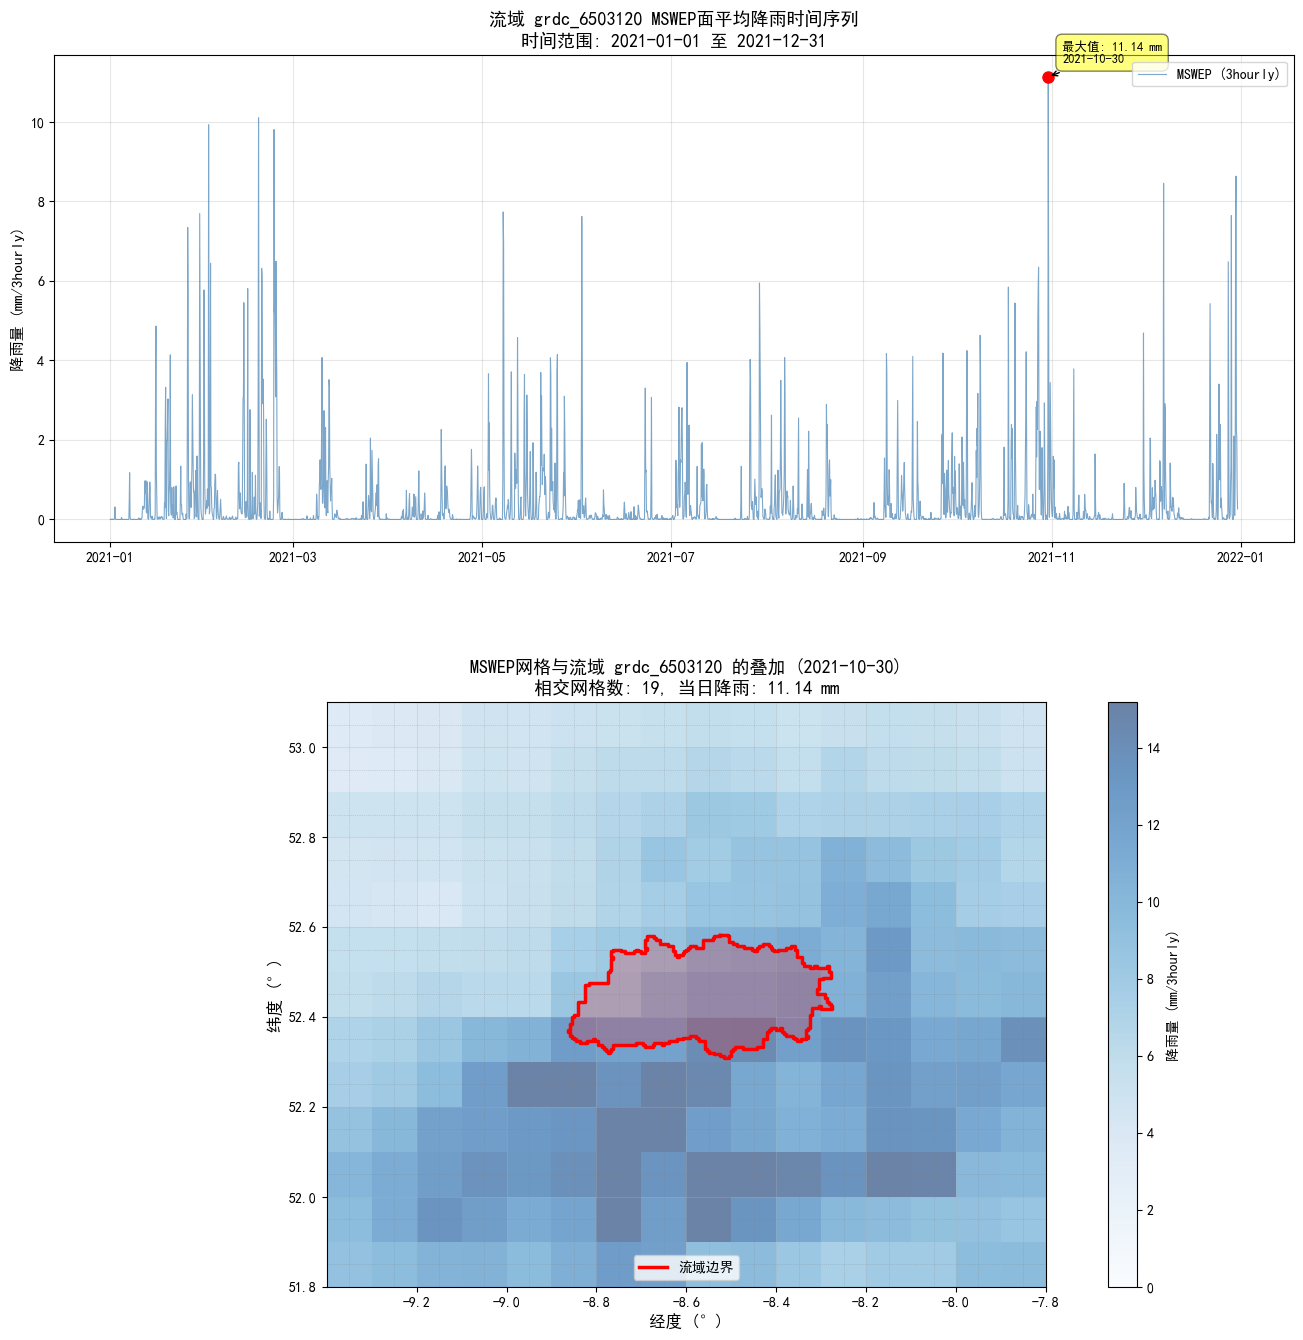


✓ MSWEP可视化完成


In [14]:
# 1. 从CSV读取数据
print("从CSV文件读取MSWEP数据...")
csv_files = glob.glob(os.path.join("results", "*mswep*.csv"))
if len(csv_files) == 0:
    print("未找到MSWEP的CSV文件，请先运行4.2和4.3节")
else:
    # 读取最新的CSV文件
    latest_csv = max(csv_files, key=os.path.getmtime)
    print(f"  读取文件: {os.path.basename(latest_csv)}")

    # 读取元数据（从注释行）- 检测时间尺度
    time_scale_str = "daily"  # 默认值
    with open(latest_csv, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('#   Time Scale:'):
                time_scale_str = line.split(':')[1].strip()
                break
    print(f"  时间尺度: {time_scale_str}")

    # 跳过元数据行，读取数据
    df = pd.read_csv(latest_csv, comment='#')
    df['time'] = pd.to_datetime(df['time'])

    # 2. 检测流域数量
    basin_columns = [col for col in df.columns if col != 'time']
    num_basins = len(basin_columns)
    print(f"  检测到 {num_basins} 个流域: {basin_columns}")

    # 3. 选择示例流域（默认第一个）
    example_basin_id = basin_columns[0]
    print(f"  使用流域 {example_basin_id} 进行可视化")

    # 获取该流域的几何对象
    example_basin_row = basins_gdf[basins_gdf['BASIN_ID'] == example_basin_id].iloc[0]
    example_basin_geom = example_basin_row.geometry

    # 找到降雨量最大的那一天
    max_idx = df[example_basin_id].idxmax()
    max_date = df.loc[max_idx, 'time']
    print(f"  最大降雨日期: {max_date.strftime('%Y-%m-%d')}")

    # 4. 创建图形：2行1列
    fig = plt.figure(figsize=(16, 16))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2], hspace=0.3)

    # 子图1: 降雨时序图
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df['time'], df[example_basin_id],
             linewidth=0.8, color='steelblue', alpha=0.7, label=f'MSWEP ({time_scale_str})')
    ax1.set_ylabel(f'降雨量 (mm/{time_scale_str})', fontsize=11)
    ax1.set_title(f'流域 {example_basin_id} MSWEP面平均降雨时间序列\n时间范围: {df["time"].min().strftime("%Y-%m-%d")} 至 {df["time"].max().strftime("%Y-%m-%d")}',
                  fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # 标注最大值
    max_val = df.loc[max_idx, example_basin_id]
    ax1.plot(max_date, max_val, 'ro', markersize=8)
    ax1.annotate(f'最大值: {max_val:.2f} mm\n{max_date.strftime("%Y-%m-%d")}',
                 xy=(max_date, max_val), xytext=(10, 10),
                 textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.5),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    # 子图2: 网格叠加图（使用降雨最大的那天）
    ax2 = fig.add_subplot(gs[1])

    # 根据时间尺度构造文件名
    if time_scale_str == 'daily':
        # 日尺度：YYYYDDD.nc
        doy = max_date.dayofyear
        target_filename = f"{max_date.year}{doy:03d}.nc"
    else:
        # 3hourly: YYYYDDD.HH.nc
        doy = max_date.dayofyear
        hour = max_date.hour
        target_filename = f"{max_date.year}{doy:03d}.{hour:02d}.nc"

    target_file = os.path.join(MSWEP_DATA_DIR, target_filename)
    print(f"  读取最大降雨日数据: {target_filename}")

    if os.path.exists(target_file):
        sample_ds = xr.open_dataset(target_file)
        lat_name = 'lat' if 'lat' in sample_ds.coords else 'latitude'
        lon_name = 'lon' if 'lon' in sample_ds.coords else 'longitude'

        prcp_var = None
        for var in ['precipitation', 'precip', 'pr', 'prcp']:
            if var in sample_ds.data_vars:
                prcp_var = var
                break
        if prcp_var is None:
            prcp_var = list(sample_ds.data_vars)[0]

        # 裁剪到流域范围
        minx, miny, maxx, maxy = example_basin_geom.bounds
        margin = 0.5

        lats_vals = sample_ds[lat_name].values
        if lats_vals[0] > lats_vals[-1]:
            lat_slice = slice(maxy + margin, miny - margin)
        else:
            lat_slice = slice(miny - margin, maxy + margin)

        ds_cropped = sample_ds.sel({
            lat_name: lat_slice,
            lon_name: slice(minx - margin, maxx + margin)
        })

        lats = ds_cropped[lat_name].values
        lons = ds_cropped[lon_name].values
        prcp_data = ds_cropped[prcp_var].values
        if prcp_data.ndim == 3:
            prcp_data = prcp_data[0]

        sample_ds.close()

        # 绘制降雨背景
        im = ax2.pcolormesh(lons, lats, prcp_data,
                           cmap='Blues', alpha=0.6, shading='auto',
                           vmin=0, vmax=np.percentile(prcp_data[prcp_data>0], 95) if (prcp_data>0).any() else 1)
        plt.colorbar(im, ax=ax2, label=f'降雨量 (mm/{time_scale_str})')

        # 绘制网格线
        resolution_lat = abs(np.diff(lats).mean())
        resolution_lon = abs(np.diff(lons).mean())
        for lat in lats[::max(1, len(lats)//15)]:
            ax2.axhline(y=lat, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
        for lon in lons[::max(1, len(lons)//15)]:
            ax2.axvline(x=lon, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

        # 绘制流域边界
        if example_basin_geom.geom_type == 'Polygon':
            x, y = example_basin_geom.exterior.xy
            ax2.plot(x, y, 'r-', linewidth=2.5, label='流域边界')
            ax2.fill(x, y, color='red', alpha=0.2)
        elif example_basin_geom.geom_type == 'MultiPolygon':
            for polygon in example_basin_geom.geoms:
                x, y = polygon.exterior.xy
                ax2.plot(x, y, 'r-', linewidth=2.5)
                ax2.fill(x, y, color='red', alpha=0.2)

        # 统计网格覆盖
        grid_count = 0
        for lat in lats:
            for lon in lons:
                grid_cell = box(lon - resolution_lon/2, lat - resolution_lat/2,
                               lon + resolution_lon/2, lat + resolution_lat/2)
                if grid_cell.intersects(example_basin_geom):
                    grid_count += 1

        ax2.set_xlabel('经度 (°)', fontsize=12)
        ax2.set_ylabel('纬度 (°)', fontsize=12)
        ax2.set_title(f'MSWEP网格与流域 {example_basin_id} 的叠加 ({max_date.strftime("%Y-%m-%d")})\n相交网格数: {grid_count}, 当日降雨: {max_val:.2f} mm',
                     fontsize=13, fontweight='bold')
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
    else:
        ax2.text(0.5, 0.5, f'未找到文件: {target_filename}',
                ha='center', va='center', fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"\n✓ MSWEP可视化完成")

## 5. 加载GFS数据并计算流域面平均降雨

5.1 设置GFS数据配置

In [ ]:
# ============ GFS数据配置 ============
GFS_DATA_DIR = "gfs"           # 数据文件夹路径
GFS_START_DATE = "2024-01-01"  # 开始日期
GFS_END_DATE = "2024-12-31"    # 结束日期
# ========================================

print(f"GFS数据处理配置:")
print(f"  数据目录: {GFS_DATA_DIR}")
print(f"  时间范围: {GFS_START_DATE} 至 {GFS_END_DATE}")
print(f"  流域: {list(selected_basins['BASIN_ID'])}")
print(f"  流域数量: {len(selected_basins)}")

5.2 处理GFS数据并计算（调用公共函数）

In [ ]:


def parse_gfs_filename(filename):
    """
    从GFS文件名解析日期
    
    参数:
        filename: 文件名 (例如 "gfs_precip_20240130.tif")
    
    返回:
        datetime对象
    """
    basename = os.path.basename(filename)
    # 匹配8位日期 YYYYMMDD
    import re
    match = re.search(r'(\d{8})', basename)
    if match:
        date_str = match.group(1)
        date = pd.to_datetime(date_str, format='%Y%m%d')
        return date
    return None

def get_gfs_files_in_range(data_dir, start_date, end_date):
    """
    获取时间范围内的GFS TIF文件列表
    
    参数:
        data_dir: 数据目录
        start_date: 开始日期 (字符串 "YYYY-MM-DD")
        end_date: 结束日期 (字符串 "YYYY-MM-DD")
    
    返回:
        文件列表和对应的日期列表
    """
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    
    all_files = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
    selected_files = []
    selected_dates = []
    
    for file in all_files:
        date = parse_gfs_filename(file)
        if date is not None and start <= date <= end:
            selected_files.append(file)
            selected_dates.append(date)
    
    return selected_files, selected_dates

def process_gfs_basin_mean(data_dir, selected_basins, start_date, end_date, random_seed=42):
    """
    处理GFS TIF数据并计算流域面平均降雨
    
    参数:
        data_dir: GFS数据目录
        selected_basins: GeoDataFrame 选中的流域
        start_date: 开始日期
        end_date: 结束日期
        random_seed: 随机种子
    
    返回:
        DataFrame: 第一列是时间，后续列是各个流域的降雨
        metadata: 元数据字典
    """
    print(f"正在处理 {len(selected_basins)} 个流域的GFS数据...")
    start_time = time.time()
    
    # 获取流域信息
    num_basins = len(selected_basins)
    basin_ids = selected_basins['BASIN_ID'].tolist()
    basin_areas = selected_basins['AREA'].tolist()
    
    print(f"  流域数量: {num_basins}")
    print(f"  流域列表: {basin_ids if num_basins <= 5 else basin_ids[:5] + ['...']}")
    print(f"  总面积: {sum(basin_areas):.2f} km²")
    
    # 1. 获取文件列表
    files, dates = get_gfs_files_in_range(data_dir, start_date, end_date)
    print(f"  找到 {len(files)} 个文件在时间范围内")
    
    if len(files) == 0:
        raise FileNotFoundError(f"在时间范围 {start_date} 至 {end_date} 内未找到数据文件")
    
    # 2. 为每个流域计算权重
    print(f"  计算各流域网格权重...")
    weights_list = []
    grid_info_list = []
    
    # 读取第一个文件获取网格信息
    with rasterio.open(files[0]) as src:
        # 获取空间分辨率和范围
        transform = src.transform
        width = src.width
        height = src.height
        
        # 生成经纬度网格
        cols, rows = np.meshgrid(np.arange(width), np.arange(height))
        lons, lats = rasterio.transform.xy(transform, rows, cols)
        
        lons = np.array(lons)
        lats = np.array(lats)
        
        # 获取所有流域的总边界范围（用于裁剪）
        all_bounds = selected_basins.total_bounds
        minx, miny, maxx, maxy = all_bounds
        margin = 0.5
        
        # 创建裁剪后的经纬度数组
        mask_x = (lons >= minx - margin) & (lons <= maxx + margin)
        mask_y = (lats >= miny - margin) & (lats <= maxy + margin)
        mask = mask_x & mask_y
        
        # 获取裁剪区域的行列索引
        rows_idx = np.where(mask.any(axis=1))[0]
        cols_idx = np.where(mask.any(axis=0))[0]
        
        if len(rows_idx) == 0 or len(cols_idx) == 0:
            raise ValueError("流域范围与GFS数据范围不重叠")
        
        row_start, row_end = rows_idx[0], rows_idx[-1] + 1
        col_start, col_end = cols_idx[0], cols_idx[-1] + 1
        
        # 裁剪后的经纬度
        lats_cropped = lats[row_start:row_end, col_start:col_end]
        lons_cropped = lons[row_start:row_end, col_start:col_end]
        
        # 使用中心点作为网格坐标
        lats_1d = lats_cropped[:, 0]
        lons_1d = lons_cropped[0, :]
    
    print(f"  网格大小: {len(lats_1d)} × {len(lons_1d)}")
    
    # 为每个流域计算权重
    total_valid_grids = 0
    for idx, (_, basin_row) in enumerate(selected_basins.iterrows()):
        basin_geom = basin_row.geometry
        basin_id = basin_row['BASIN_ID']
        
        weights = calculate_grid_weights_fast(basin_geom, lats_1d, lons_1d)
        valid_grids = (weights > 0).sum()
        total_valid_grids += valid_grids
        
        weights_list.append(weights)
        grid_info_list.append({
            'basin_id': basin_id,
            'valid_grids': valid_grids
        })
        
        if (idx + 1) % 10 == 0 or idx == 0:
            print(f"    流域 {idx+1}/{num_basins}: {basin_id}, 有效网格: {valid_grids}")
    
    # 3. 逐文件处理并计算各流域加权平均
    print(f"  开始计算流域面平均降雨...")
    results = []
    
    for idx, (file, date) in enumerate(zip(files, dates)):
        if (idx + 1) % 50 == 0:
            print(f"    已处理 {idx+1}/{len(files)} 个文件...")
        
        try:
            with rasterio.open(file) as src:
                # 读取裁剪区域的数据
                prcp_data = src.read(1, window=((row_start, row_end), (col_start, col_end)))
                
                # 处理无效值
                prcp_data = np.where(prcp_data < 0, 0, prcp_data)
                prcp_data = np.where(np.isnan(prcp_data), 0, prcp_data)
            
            # 计算各流域加权平均
            record = {'time': date}
            for basin_idx, basin_id in enumerate(basin_ids):
                basin_mean = np.sum(prcp_data * weights_list[basin_idx])
                record[basin_id] = basin_mean
            
            results.append(record)
            
        except Exception as e:
            print(f"    警告: 处理文件 {os.path.basename(file)} 失败: {e}")
            continue
    
    # 4. 创建DataFrame
    df = pd.DataFrame(results)
    df = df.sort_values('time').reset_index(drop=True)
    
    # 重新排列列顺序: time在第一列，然后按流域ID排序
    cols = ['time'] + sorted([col for col in df.columns if col != 'time'])
    df = df[cols]
    
    elapsed_time = time.time() - start_time
    
    # 5. 创建元数据
    metadata = {
        'num_basins': num_basins,
        'start_date': start_date,
        'end_date': end_date,
        'time_scale': 'daily',
        'computation_time_seconds': elapsed_time,
        'data_source': 'GFS',
        'method': 'Grid Area-Weighted Method',
        'random_seed': random_seed
    }
    
    print(f"\n  ✓ 处理完成!")
    print(f"  时间点数: {len(df)}")
    print(f"  流域数: {num_basins}")
    print(f"  计算用时: {elapsed_time:.2f} 秒")
    
    return df, metadata

# 执行计算
gfs_basin_mean_df, gfs_metadata = process_gfs_basin_mean(
    data_dir=GFS_DATA_DIR,
    selected_basins=selected_basins,
    start_date=GFS_START_DATE,
    end_date=GFS_END_DATE,
    random_seed=42  # 与notebook 1保持一致
)

# 显示结果
print(f"\nGFS流域面平均降雨数据预览:")
print(gfs_basin_mean_df.head(10))

print(f"\n计算元数据:")
print(f"  流域数量: {gfs_metadata['num_basins']}")
print(f"  时间范围: {gfs_metadata['start_date']} 至 {gfs_metadata['end_date']}")
print(f"  记录数: {len(gfs_basin_mean_df)}")
print(f"  随机种子: {gfs_metadata['random_seed']}")

5.3 保存GFS数据到CSV

In [ ]:
# 创建输出目录
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# 生成文件名
if gfs_metadata['num_basins'] == 1:
    gfs_output_filename = f"{list(selected_basins['BASIN_ID'])[0]}_gfs_daily_{GFS_START_DATE}_{GFS_END_DATE}.csv"
else:
    gfs_output_filename = f"{gfs_metadata['num_basins']}_basins_gfs_daily_{GFS_START_DATE}_{GFS_END_DATE}.csv"

gfs_output_path = os.path.join(output_dir, gfs_output_filename)

# 保存为CSV，在文件开头写入元数据作为注释
with open(gfs_output_path, 'w', encoding='utf-8') as f:
    # 写入元数据表头
    f.write("# GFS Basin Mean Precipitation\n")
    f.write(f"# Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("#\n")
    f.write("# Metadata:\n")
    f.write(f"#   Number of Basins: {gfs_metadata['num_basins']}\n")
    f.write(f"#   Time Period: {gfs_metadata['start_date']} to {gfs_metadata['end_date']}\n")
    f.write(f"#   Time Scale: {gfs_metadata['time_scale']}\n")
    f.write(f"#   Data Source: {gfs_metadata['data_source']}\n")
    f.write(f"#   Method: {gfs_metadata['method']}\n")
    f.write(f"#   Computation Time: {gfs_metadata['computation_time_seconds']:.2f} seconds\n")
    f.write(f"#   Random Seed: {gfs_metadata['random_seed']}\n")
    f.write("#\n")
    
    # 写入数据
    gfs_basin_mean_df.to_csv(f, index=False)

print(f"✓ GFS结果已保存!")
print(f"  文件路径: {gfs_output_path}")
print(f"  文件大小: {os.path.getsize(gfs_output_path) / 1024:.2f} KB")

print(f"\nCSV文件格式:")
print(f"  第1列: time - 时间")
if gfs_metadata['num_basins'] == 1:
    print(f"  第2列: {list(selected_basins['BASIN_ID'])[0]} - 流域面平均降雨量 (mm)")
else:
    print(f"  第2-{gfs_metadata['num_basins']+1}列: 各流域ID - 流域面平均降雨量 (mm)")

print(f"\n元数据摘要:")
print(f"  流域数量: {gfs_metadata['num_basins']}")
print(f"  时间范围: {gfs_metadata['start_date']} 至 {gfs_metadata['end_date']}")
print(f"  时间尺度: {gfs_metadata['time_scale']}")
print(f"  数据源: {gfs_metadata['data_source']}")
print(f"  计算方法: {gfs_metadata['method']}")
print(f"  计算用时: {gfs_metadata['computation_time_seconds']:.2f} 秒")
print(f"  随机种子: {gfs_metadata['random_seed']}")

# 统计总降雨量
basin_ids = list(selected_basins['BASIN_ID'])
print(f"\n降雨统计 (前5个流域):")
for basin_id in basin_ids[:5]:
    if basin_id in gfs_basin_mean_df.columns:
        total = gfs_basin_mean_df[basin_id].sum()
        mean = gfs_basin_mean_df[basin_id].mean()
        max_val = gfs_basin_mean_df[basin_id].max()
        print(f"  {basin_id}: 总={total:.2f} mm, 均值={mean:.2f} mm, 最大={max_val:.2f} mm")

5.4 可视化GFS示例流域降雨数据

In [ ]:
# 1. 从CSV读取数据
print("从CSV文件读取GFS数据...")
csv_files = glob.glob(os.path.join("results", "*gfs*.csv"))
if len(csv_files) == 0:
    print("未找到GFS的CSV文件，请先运行5.2和5.3节")
else:
    # 读取最新的CSV文件
    latest_csv = max(csv_files, key=os.path.getmtime)
    print(f"  读取文件: {os.path.basename(latest_csv)}")

    # 读取元数据（从注释行）- 检测时间尺度
    time_scale_str = "daily"  # GFS默认是daily
    with open(latest_csv, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('#   Time Scale:'):
                time_scale_str = line.split(':')[1].strip()
                break
    print(f"  时间尺度: {time_scale_str}")

    # 跳过元数据行，读取数据
    df = pd.read_csv(latest_csv, comment='#')
    df['time'] = pd.to_datetime(df['time'])

    # 2. 检测流域数量
    basin_columns = [col for col in df.columns if col != 'time']
    num_basins = len(basin_columns)
    print(f"  检测到 {num_basins} 个流域: {basin_columns}")

    # 3. 选择示例流域（默认第一个）
    example_basin_id = basin_columns[0]
    print(f"  使用流域 {example_basin_id} 进行可视化")

    # 获取该流域的几何对象
    example_basin_row = basins_gdf[basins_gdf['BASIN_ID'] == example_basin_id].iloc[0]
    example_basin_geom = example_basin_row.geometry

    # 找到降雨量最大的那一天
    max_idx = df[example_basin_id].idxmax()
    max_date = df.loc[max_idx, 'time']
    print(f"  最大降雨日期: {max_date.strftime('%Y-%m-%d')}")

    # 4. 创建图形：2行1列
    fig = plt.figure(figsize=(16, 16))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2], hspace=0.3)

    # 子图1: 降雨时序图
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df['time'], df[example_basin_id],
             linewidth=0.8, color='orange', alpha=0.7, label=f'GFS ({time_scale_str})')
    ax1.set_ylabel(f'降雨量 (mm/{time_scale_str})', fontsize=11)
    ax1.set_title(f'流域 {example_basin_id} GFS面平均降雨时间序列\n时间范围: {df["time"].min().strftime("%Y-%m-%d")} 至 {df["time"].max().strftime("%Y-%m-%d")}',
                  fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # 标注最大值
    max_val = df.loc[max_idx, example_basin_id]
    ax1.plot(max_date, max_val, 'ro', markersize=8)
    ax1.annotate(f'最大值: {max_val:.2f} mm\n{max_date.strftime("%Y-%m-%d")}',
                 xy=(max_date, max_val), xytext=(10, 10),
                 textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.5),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    # 子图2: 网格叠加图（使用降雨最大的那天）
    ax2 = fig.add_subplot(gs[1])

    # GFS文件名格式: gfs_precip_YYYYMMDD.tif 或其他包含8位日期的格式
    target_date_str = max_date.strftime('%Y%m%d')

    # 查找包含该日期的文件
    gfs_files = glob.glob(os.path.join(GFS_DATA_DIR, f"*{target_date_str}*.tif"))

    if len(gfs_files) == 0:
        # 如果没找到，尝试查找所有tif文件并匹配日期
        all_gfs_files = glob.glob(os.path.join(GFS_DATA_DIR, "*.tif"))
        import re
        for f in all_gfs_files:
            if target_date_str in os.path.basename(f):
                gfs_files.append(f)

    print(f"  读取最大降雨日数据: {target_date_str}")

    if len(gfs_files) > 0:
        target_file = gfs_files[0]
        with rasterio.open(target_file) as src:
            transform = src.transform
            width = src.width
            height = src.height

            cols, rows = np.meshgrid(np.arange(width), np.arange(height))
            lons_full, lats_full = rasterio.transform.xy(transform, rows, cols)
            lons_full = np.array(lons_full)
            lats_full = np.array(lats_full)

            # 裁剪到流域范围
            minx, miny, maxx, maxy = example_basin_geom.bounds
            margin = 0.5

            mask_x = (lons_full >= minx - margin) & (lons_full <= maxx + margin)
            mask_y = (lats_full >= miny - margin) & (lats_full <= maxy + margin)
            mask = mask_x & mask_y

            rows_idx = np.where(mask.any(axis=1))[0]
            cols_idx = np.where(mask.any(axis=0))[0]

            if len(rows_idx) > 0 and len(cols_idx) > 0:
                row_start, row_end = rows_idx[0], rows_idx[-1] + 1
                col_start, col_end = cols_idx[0], cols_idx[-1] + 1

                prcp_data = src.read(1, window=((row_start, row_end), (col_start, col_end)))
                prcp_data = np.where(prcp_data < 0, 0, prcp_data)
                prcp_data = np.where(np.isnan(prcp_data), 0, prcp_data)

                lats_cropped = lats_full[row_start:row_end, col_start:col_end]
                lons_cropped = lons_full[row_start:row_end, col_start:col_end]
                lats = lats_cropped[:, 0]
                lons = lons_cropped[0, :]

                # 绘制降雨背景
                im = ax2.pcolormesh(lons, lats, prcp_data,
                                   cmap='Oranges', alpha=0.6, shading='auto',
                                   vmin=0, vmax=np.percentile(prcp_data[prcp_data>0], 95) if (prcp_data>0).any() else 1)
                plt.colorbar(im, ax=ax2, label=f'降雨量 (mm/{time_scale_str})')

                # 绘制网格线
                resolution_lat = abs(np.diff(lats).mean())
                resolution_lon = abs(np.diff(lons).mean())
                for lat in lats[::max(1, len(lats)//15)]:
                    ax2.axhline(y=lat, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
                for lon in lons[::max(1, len(lons)//15)]:
                    ax2.axvline(x=lon, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

                # 绘制流域边界
                if example_basin_geom.geom_type == 'Polygon':
                    x, y = example_basin_geom.exterior.xy
                    ax2.plot(x, y, 'r-', linewidth=2.5, label='流域边界')
                    ax2.fill(x, y, color='red', alpha=0.2)
                elif example_basin_geom.geom_type == 'MultiPolygon':
                    for polygon in example_basin_geom.geoms:
                        x, y = polygon.exterior.xy
                        ax2.plot(x, y, 'r-', linewidth=2.5)
                        ax2.fill(x, y, color='red', alpha=0.2)

                # 统计网格覆盖
                grid_count = 0
                for lat in lats:
                    for lon in lons:
                        grid_cell = box(lon - resolution_lon/2, lat - resolution_lat/2,
                                       lon + resolution_lon/2, lat + resolution_lat/2)
                        if grid_cell.intersects(example_basin_geom):
                            grid_count += 1

                ax2.set_xlabel('经度 (°)', fontsize=12)
                ax2.set_ylabel('纬度 (°)', fontsize=12)
                ax2.set_title(f'GFS网格 (0.25°) 与流域 {example_basin_id} 的叠加 ({max_date.strftime("%Y-%m-%d")})\n相交网格数: {grid_count}, 当日降雨: {max_val:.2f} mm',
                             fontsize=13, fontweight='bold')
                ax2.legend(loc='best', fontsize=10)
                ax2.grid(True, alpha=0.3)
                ax2.set_aspect('equal')
    else:
        ax2.text(0.5, 0.5, f'未找到日期 {target_date_str} 的GFS文件',
                ha='center', va='center', fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"\n✓ GFS可视化完成")